# Lista de Processamento Digital de Sinais (PDS)

Este notebook implementa os algoritmos e gráficos utilizando o ecossistema científico do Python (`NumPy`, `Matplotlib` e `SciPy`). 

Certifique-se de ter as dependências instaladas no seu ambiente virtual:
`pip install numpy matplotlib scipy`

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Espectro de uma Senoide Discreta

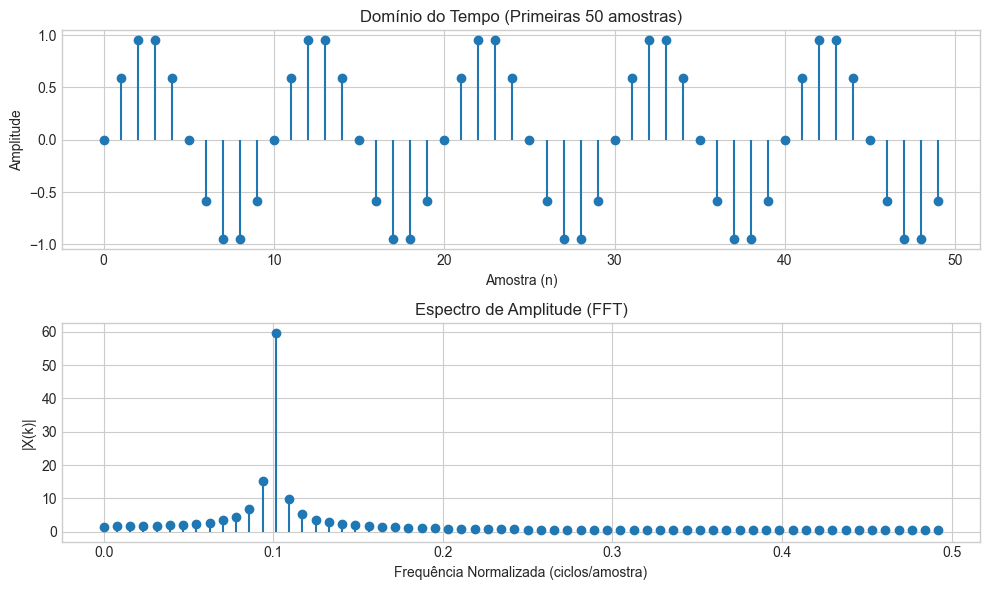

In [13]:
N = 128
n = np.arange(N)
f0 = 0.1
x = np.sin(2 * np.pi * f0 * n)

X = np.abs(np.fft.fft(x))
f_norm = np.arange(N) / N

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.stem(n[:50], x[:50], basefmt=" ")
plt.title('Domínio do Tempo (Primeiras 50 amostras)')
plt.xlabel('Amostra (n)')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.stem(f_norm[:N//2], X[:N//2], basefmt=" ")
plt.title('Espectro de Amplitude (FFT)')
plt.xlabel('Frequência Normalizada (ciclos/amostra)')
plt.ylabel('|X(k)|')

plt.tight_layout()
plt.show()

No domínio da frequência, a energia do sinal concentra-se exatamente em $f = 0.1$, confirmando a frequência dominante. O pico simétrico apareceria acima da frequência de Nyquist ($f > 0.5$), mas limitamos o plot a $N/2$ para clareza em sinais reais.

## 2. Separação de Componentes e Relação Tempo-Frequência

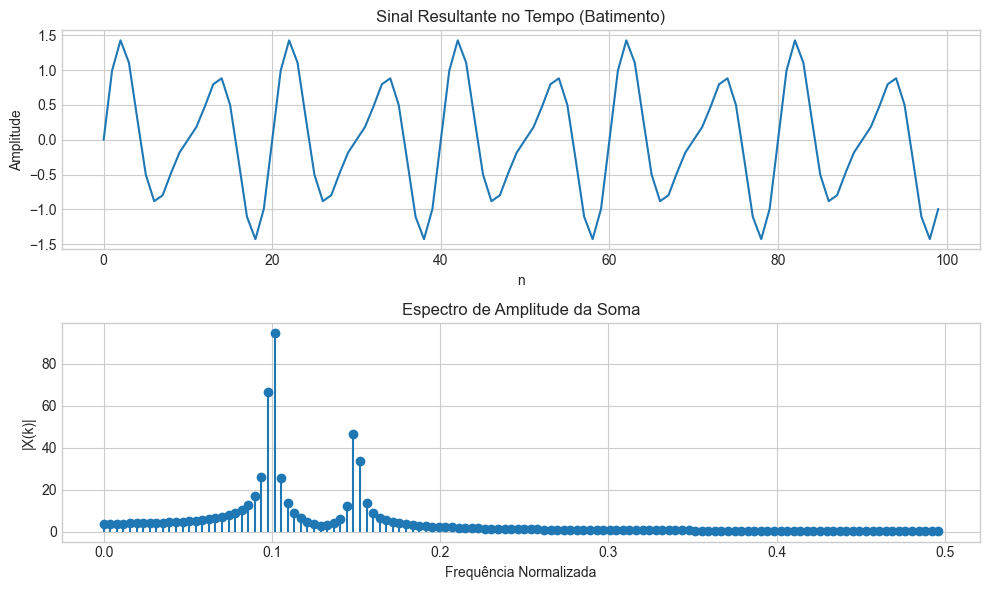

In [14]:
N = 256
n = np.arange(N)
f1, f2 = 0.1, 0.15
x_soma = np.sin(2 * np.pi * f1 * n) + 0.5 * np.sin(2 * np.pi * f2 * n)

X_soma = np.abs(np.fft.fft(x_soma))
f_norm = np.arange(N) / N

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(n[:100], x_soma[:100])
plt.title('Sinal Resultante no Tempo (Batimento)')
plt.xlabel('n')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.stem(f_norm[:N//2], X_soma[:N//2], basefmt=" ")
plt.title('Espectro de Amplitude da Soma')
plt.xlabel('Frequência Normalizada')
plt.ylabel('|X(k)|')

plt.tight_layout()
plt.show()

A relação entre os domínios é complementar. No domínio do tempo, a superposição de frequências próximas gera interferência construtiva e destrutiva (conhecido como *batimento*), dificultando a visualização direta das características de cada senoide original. No entanto, através da transformação para o domínio da frequência via FFT, o princípio da superposição garante que a energia seja ortogonalizada em *bins* espectrais distintos, permitindo separar as duas componentes claramente em $f = 0.1$ e $f = 0.15$.

## 3. Aliasing (Subamostragem)

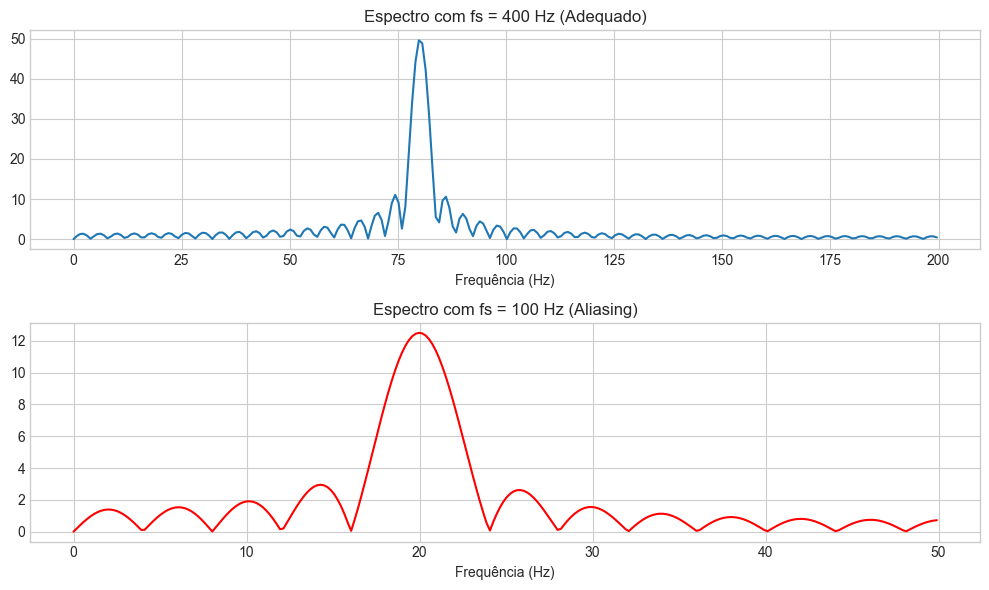

In [15]:
f_sinal = 80  # Sinal analógico a 80 Hz
fs_alta = 400 # Amostragem adequada (> 2*f_sinal)
fs_baixa = 100 # Subamostragem (< 2*f_sinal)

t_alta = np.arange(0, 0.25, 1/fs_alta)
t_baixa = np.arange(0, 0.25, 1/fs_baixa)

x_alta = np.sin(2 * np.pi * f_sinal * t_alta)
x_baixa = np.sin(2 * np.pi * f_sinal * t_baixa)

X_alta = np.abs(np.fft.fft(x_alta, 512))
X_baixa = np.abs(np.fft.fft(x_baixa, 512))

f_eixo_alta = np.linspace(0, fs_alta, 512)
f_eixo_baixa = np.linspace(0, fs_baixa, 512)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(f_eixo_alta[:256], X_alta[:256])
plt.title('Espectro com fs = 400 Hz (Adequado)')
plt.xlabel('Frequência (Hz)')

plt.subplot(2, 1, 2)
plt.plot(f_eixo_baixa[:256], X_baixa[:256], color='red')
plt.title('Espectro com fs = 100 Hz (Aliasing)')
plt.xlabel('Frequência (Hz)')

plt.tight_layout()
plt.show()

 O Teorema de Nyquist-Shannon estabelece que a frequência de amostragem deve ser $f_s > 2f_{max}$. Ao usar $f_s = 100\text{ Hz}$ para um sinal de $80\text{ Hz}$, ocorre o espelhamento da frequência. A energia não desaparece, mas sim dobra sobre a frequência de Nyquist ($50\text{ Hz}$), criando uma falsa componente ("alias") observada na frequência fundamental de $|100 - 80| = 20\text{ Hz}$. Isso corrompe a integridade da análise digital do sinal.

## 4. Vazamento Espectral e Janelamento

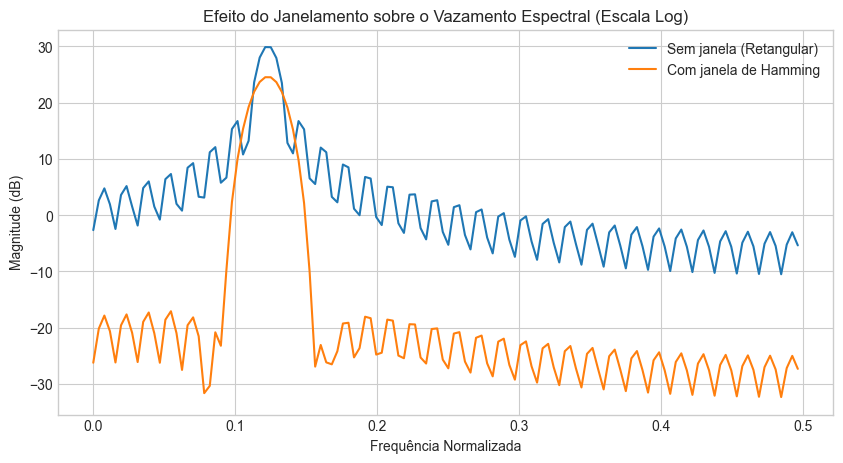

In [16]:
N = 64
n = np.arange(N)
f0 = 0.123 # Frequência fracionária
x = np.sin(2 * np.pi * f0 * n)

janela = np.hamming(N)
x_janelado = x * janela

N_fft = 256 # Zero-padding
# Adiciona  epsilon para evitar log(0)
X = 20 * np.log10(np.abs(np.fft.fft(x, N_fft)) + 1e-12)
X_janelado = 20 * np.log10(np.abs(np.fft.fft(x_janelado, N_fft)) + 1e-12)
f_norm = np.arange(N_fft) / N_fft

plt.figure(figsize=(10, 5))
plt.plot(f_norm[:N_fft//2], X[:N_fft//2], label='Sem janela (Retangular)', linewidth=1.5)
plt.plot(f_norm[:N_fft//2], X_janelado[:N_fft//2], label='Com janela de Hamming', linewidth=1.5)
plt.title('Efeito do Janelamento sobre o Vazamento Espectral (Escala Log)')
plt.xlabel('Frequência Normalizada')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.show()

 Como a frequência de $0.123$ não gera um número inteiro de ciclos em $N=64$, o truncamento abrupto atua como uma janela retangular, inserindo descontinuidades extremas nas bordas do sinal no domínio do tempo. Isso provoca *spectral leakage* (vazamento), espalhando a energia pelos lobos laterais, mascarando sinais adjacentes. A janela de Hamming atenua progressivamente os extremos do sinal a zero, sacrificando um pouco a resolução central (lobo principal mais largo), mas reduzindo drasticamente os lobos laterais em dB, o que melhora o isolamento dinâmico.

## 5. Extração de Sinais em Presença de Ruído Aditivo

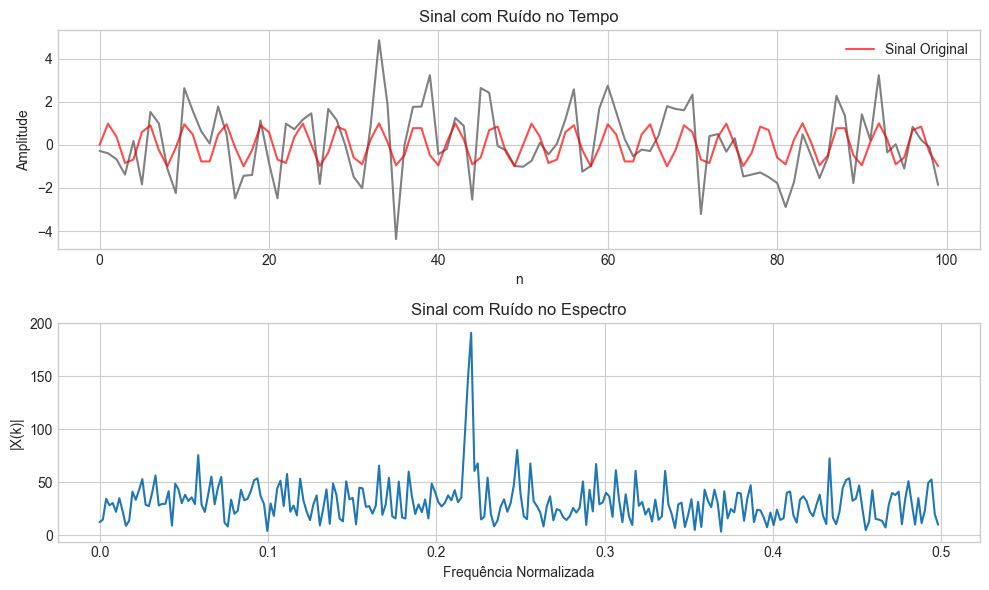

In [17]:
N = 512
n = np.arange(N)
f0 = 0.22
sinal = np.sin(2 * np.pi * f0 * n)
ruido = 1.5 * np.random.randn(N)
x_ruidoso = sinal + ruido

X = np.abs(np.fft.fft(x_ruidoso))
f_norm = np.arange(N) / N

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(n[:100], x_ruidoso[:100], color='gray')
plt.plot(n[:100], sinal[:100], color='red', alpha=0.7, label='Sinal Original')
plt.title('Sinal com Ruído no Tempo')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(f_norm[:N//2], X[:N//2])
plt.title('Sinal com Ruído no Espectro')
plt.xlabel('Frequência Normalizada')
plt.ylabel('|X(k)|')

plt.tight_layout()
plt.show()

 No domínio do tempo, a relação sinal-ruído (SNR) é baixa e a componente oscilatória é indistinguível, tornando complexas abordagens temporais simples como detecção de zero-crossing. A transformada de Fourier funciona atuando como um filtro de correlação estreito em múltiplos *bins*. Como o Ruído Branco Gaussiano Aditivo (AWGN) tem sua potência distribuída uniformemente por toda a faixa de frequência, sua energia por *bin* espectral é pequena. Simultaneamente, a FFT consolida toda a energia coerente do sinal em uma janela estreita na frequência $f_0$. Essa consolidação eleva instantaneamente a visualização do sinal desejado acima do piso de ruído (*noise floor*), habilitando abordagens de filtragem no domínio da frequência.

## 6. DFT Direta vs. FFT

In [18]:
x = np.array([1, 2, 3, 4, 4, 3, 2, 1])
N = len(x)

# DFT Direta O(N^2)
X_dft = np.zeros(N, dtype=complex)
for k in range(N):
    for n in range(N):
        X_dft[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)

# FFT (Algoritmo O(N log N))
X_fft = np.fft.fft(x)

erro_maximo = np.max(np.abs(X_dft - X_fft))
print(f"Erro máximo numérico entre DFT e FFT: {erro_maximo:.5e}")

Erro máximo numérico entre DFT e FFT: 7.68063e-15


 O resultado demonstra que a função genérica `fft` do NumPy calcula numericamente o exato mesmo espectro que a definição base da DFT: $$X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi k n / N}$$
A grande diferença, contudo, é a topologia de operação e o custo computacional. A equação direta possui complexidade temporal $\mathcal{O}(N^2)$ e escala inviavelmente mal para arrays grandes. A implementação da FFT explora a simetria rotacional das raízes da unidade em um modelo *divide and conquer* para condensar o custo em $\mathcal{O}(N \log_2 N)$.

## 7. Análise de Função de Transferência Discreta

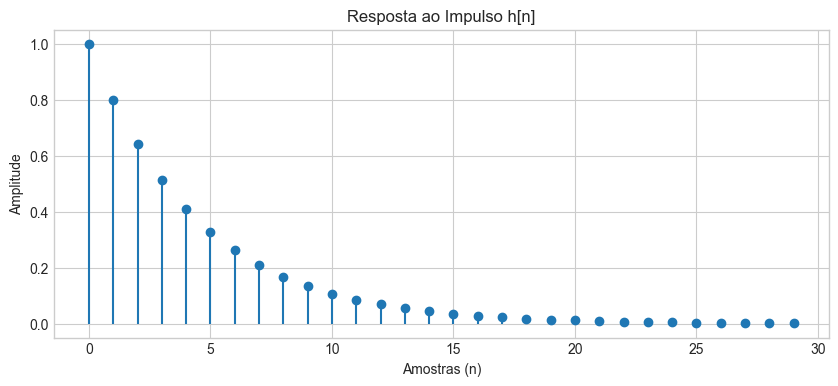

In [19]:
num = [1.0]
den = [1.0, -0.8]

n = np.arange(30)
impulso = signal.unit_impulse(30)
h = signal.lfilter(num, den, impulso)

plt.figure(figsize=(10, 4))
plt.stem(n, h, basefmt=" ")
plt.title('Resposta ao Impulso h[n]')
plt.xlabel('Amostras (n)')
plt.ylabel('Amplitude')
plt.show()

 A equação de diferenças corresponde ao sistema $y[n] = 0.8 y[n-1] + x[n]$, caracterizando um modelo IIR simples. Ao analisar os polos do sistema no plano Z, o sistema possui um polo em $z = 0.8$. A Região de Convergência (ROC) pode incluir o círculo unitário uma vez que o módulo do polo é menor que 1 ($|0.8| < 1$). Dessa forma, sua resposta impulsional decai exponencialmente ($0.8^n u[n]$). O sistema é categorizado como Bounded-Input Bounded-Output (BIBO) estável.

## 8. Resolução Espectral

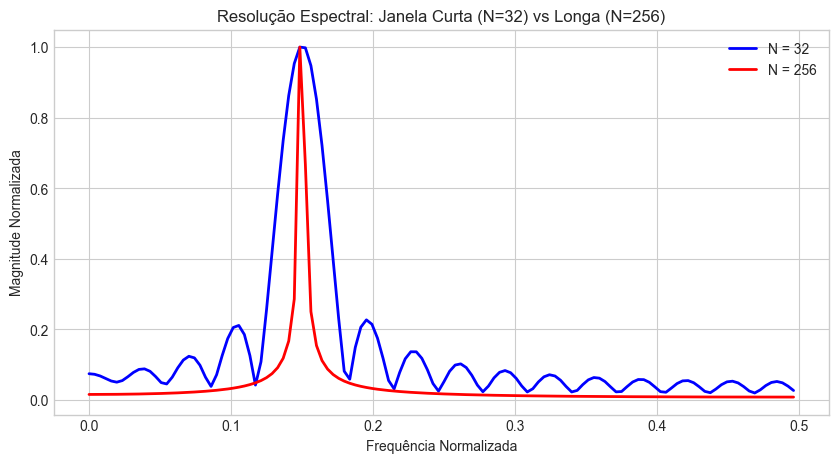

In [20]:
f0 = 0.15
N1 = 32; n1 = np.arange(N1); x1 = np.sin(2 * np.pi * f0 * n1)
N2 = 256; n2 = np.arange(N2); x2 = np.sin(2 * np.pi * f0 * n2)

# Zero-pad para sobreposição visual
X1 = np.abs(np.fft.fft(x1, 256))
X2 = np.abs(np.fft.fft(x2, 256))
f_norm = np.arange(256) / 256

plt.figure(figsize=(10, 5))
plt.plot(f_norm[:128], X1[:128] / np.max(X1), 'b', linewidth=2, label='N = 32')
plt.plot(f_norm[:128], X2[:128] / np.max(X2), 'r', linewidth=2, label='N = 256')
plt.title('Resolução Espectral: Janela Curta (N=32) vs Longa (N=256)')
plt.xlabel('Frequência Normalizada')
plt.ylabel('Magnitude Normalizada')
plt.legend()
plt.show()

 A resolução espectral analítica de um processo digital amostrado é governada pela relação $\Delta f = f_s / N$. Um tempo de observação curto ($N=32$) resulta numa definição grosseira que se traduz visualmente por um lobo principal consideravelmente mais largo. Quando o comprimento do sinal aumenta para $N=256$, o passo computacional na frequência diminui, gerando *bins* espectrais extremamente estreitos. Na prática, grandes janelas de amostragem oferecem superioridade para resolver frequências adjacentes estritamente correlacionadas.

## 9. Diagnóstico por Componentes Harmônicas

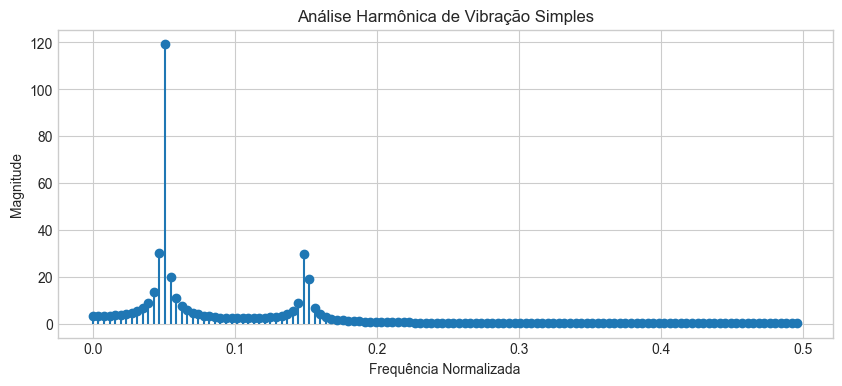

In [21]:
N = 256
n = np.arange(N)
f_fund = 0.05
f_harm3 = 3 * f_fund

x_vib = 1.0 * np.sin(2 * np.pi * f_fund * n) + 0.3 * np.sin(2 * np.pi * f_harm3 * n)
X = np.abs(np.fft.fft(x_vib))
f_norm = np.arange(N) / N

plt.figure(figsize=(10, 4))
plt.stem(f_norm[:N//2], X[:N//2], basefmt=" ")
plt.title('Análise Harmônica de Vibração Simples')
plt.xlabel('Frequência Normalizada')
plt.ylabel('Magnitude')
plt.show()

 Observa-se a manifestação da frequência fundamental ($f = 0.05$) ditando a componente de maior potência, mas claramente acompanhada por sua 3ª harmônica ($f = 0.15$). Na engenharia de manutenção e diagnóstico mecânico, o mapeamento do espectro permite inferir falhas sem intervenção direta: a fundamental tipicamente descreve a rotação natural do eixo base, enquanto picos em harmônicas exatas da rotação denotam desbalanceamentos, falhas periódicas de esferas de rolamento ou excentricidades do rotor.

## 10. Sinal Simulado de Sistema Real Subamortecido

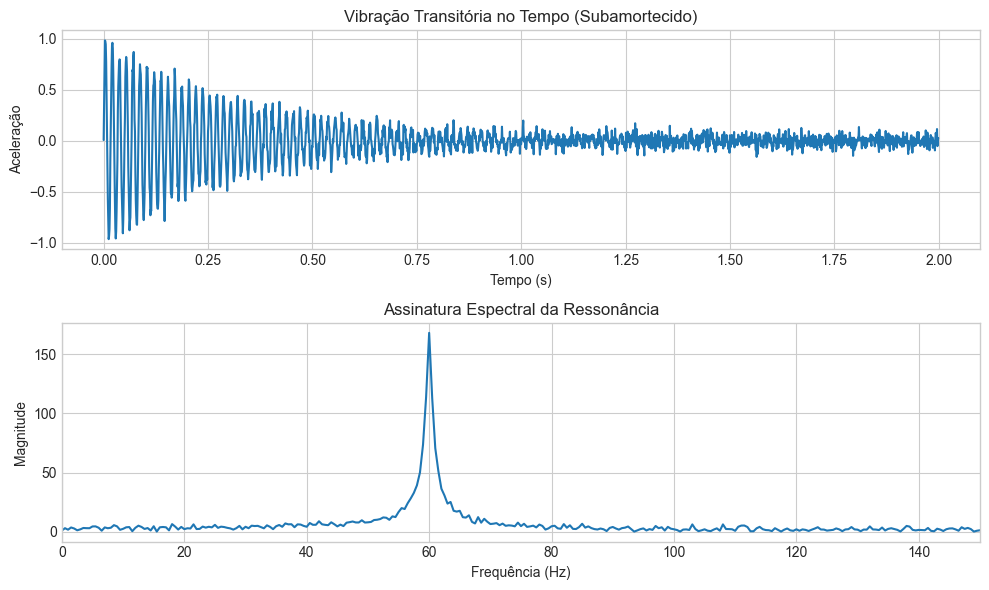

In [22]:
fs = 1000
t = np.arange(0, 2, 1/fs)
f_ressonancia = 60
alpha = 3 # Fator de amortecimento

# Sinal subamortecido com ruído de medição
x_real = np.exp(-alpha * t) * np.sin(2 * np.pi * f_ressonancia * t) + 0.05 * np.random.randn(len(t))

X_real = np.abs(np.fft.fft(x_real))
f_eixo = np.arange(len(X_real)) * fs / len(X_real)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, x_real)
plt.title('Vibração Transitória no Tempo (Subamortecido)')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração')

plt.subplot(2, 1, 2)
plt.plot(f_eixo[:len(X_real)//2], X_real[:len(X_real)//2])
plt.title('Assinatura Espectral da Ressonância')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim([0, 150])

plt.tight_layout()
plt.show()

Modelamos uma resposta transiente representativa de um sistema linear invariante no tempo impactado por um impulso ideal. A envoltória exponencial $e^{-\alpha t}$ deforma sutilmente o pico de ressonância no domínio da frequência, provocando um ensanchamento natural da banda em torno de $60\text{ Hz}$ associado à dissipação de energia. A análise espectral captura com precisão o comportamento ressonante, permitindo aos controladores ou projetistas estimarem os polos da função e validarem as premissas de malha contra as medições de campo isolando a presença do ruído sensório.